In [14]:
#hide
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

In [15]:
#hide
from fastbook import *

# Классификация изображений

Теперь, когда вы понимаете, что такое глубокое обучение, для чего оно нужно и как создавать и развертывать модели, пришло время углубиться! В идеальном мире специалистам по глубокому обучению не пришлось бы знать каждую деталь работы алгоритмов «под капотом»… Но пока мы живем не в идеальном мире. На деле, чтобы ваша модель работала по-настоящему эффективно и стабильно, нужно правильно настроить множество деталей и тщательно их проверить. Этот процесс требует возможности заглянуть внутрь вашей нейросети во время обучения и предсказаний, выявить потенциальные проблемы и знать, как их исправить.  

Итак, далее в книге мы погрузимся в механику глубокого обучения. Как устроены архитектуры моделей компьютерного зрения, NLP (Natural Language Processing, обработки естественного языка), табличных данных и других типов? Как создать архитектуру, подходящую под задачи вашей предметной области? Как добиться наилучших результатов в процессе обучения? Как ускорить работу? Что нужно менять при изменении наборов данных?  

Мы начнем с повторения базовых примеров, которые рассматривали в первой главе, но сделаем две вещи:  

- Улучшим их.  
- Применим к большему разнообразию типов данных.  

Для этого нам предстоит изучить все элементы пазла глубокого обучения. Сюда входят разные типы слоев, методы регуляризации, оптимизаторы, способы комбинирования слоев в архитектуры, техники разметки данных и многое другое. Однако мы не будем вываливать на вас все сразу — мы будем вводить их постепенно, по мере необходимости, для решения конкретных задач в рамках наших проектов.

## От собак и кошек к породам питомцев

В нашей самой первой модели мы научились классифицировать собак и кошек. Еще несколько лет назад эта задача считалась очень сложной — но сегодня она стала слишком простой! На этом примере мы не сможем показать все нюансы обучения моделей, поскольку получаем практически идеальный результат, не заботясь о деталях. Однако оказывается, что тот же набор данных позволяет нам работать над гораздо более сложной задачей: определить породу питомца на каждом изображении.

В главе \<\<chapter_intro\>\> мы представили приложения как уже решенные задачи. Но в реальной жизни все устроено иначе. Мы начинаем с какого-то набора данных, о котором ничего не знаем. Затем нам нужно разобраться, как он устроен, как извлечь нужные данные и как эти данные выглядят. В оставшейся части книги мы покажем, как решать эти задачи на практике, включая все промежуточные шаги, необходимые для понимания данных, с которыми вы работаете, и тестирования модели по мере ее создания.

Мы уже загрузили набор данных Pet и можем получить путь к нему, используя тот же код, что и в \<\<chapter_intro\>\>:

In [16]:
from fastai.vision.all import *
path = untar_data(URLs.PETS)

Чтобы понять, как извлекать породу каждого питомца из изображений, нам нужно разобраться в структуре данных. Такие детали организации данных — ключевая часть головоломки глубокого обучения. Обычно данные предоставляются в одном из двух форматов:  

- **Отдельные файлы**, представляющие элементы данных (например, текстовые документы или изображения), которые могут быть организованы в папки или иметь имена, содержащие информацию об этих элементах  
- **Табличные данные** (например, в формате CSV), где каждая строка представляет элемент и может включать имена файлов, связывающие данные таблицы с другими форматами (текстовыми документами или изображениями)  

Существуют исключения из этих правил — особенно в таких областях, как геномика, где могут встречаться бинарные форматы баз данных или даже сетевые потоки, — но в подавляющем большинстве случаев наборы данных используют комбинацию этих двух форматов.  

Чтобы посмотреть содержимое нашего набора данных, можно использовать метод `ls`:

In [17]:
#hide
Path.BASE_PATH = path

In [18]:
path.ls()

(#2) [Path('annotations'),Path('images')]

Мы видим, что этот набор данных содержит директории *images* (изображения) и *annotations* (аннотации). Согласно [сайту](https://www.robots.ox.ac.uk/~vgg/data/pets/) датасета, директория *annotations* содержит информацию о местоположении питомцев на изображениях, а не об их породах. В этой главе мы занимаемся классификацией, а не локализацией — то есть нас интересует, *что* изображено, а не *где*. Поэтому пока мы проигнорируем директорию *annotations*. Давайте посмотрим содержимое директории *images*:

In [24]:
(path/"images").ls()

(#7393) [Path('images/Siamese_183.jpg'),Path('images/Bombay_90.jpg'),Path('images/Ragdoll_122.jpg'),Path('images/keeshond_78.jpg'),Path('images/havanese_3.jpg'),Path('images/american_pit_bull_terrier_70.jpg'),Path('images/basset_hound_62.jpg'),Path('images/Sphynx_121.jpg'),Path('images/Ragdoll_170.jpg'),Path('images/english_cocker_spaniel_14.jpg'),Path('images/newfoundland_8.jpg'),Path('images/shiba_inu_38.jpg'),Path('images/english_setter_189.jpg'),Path('images/Birman_105.jpg'),Path('images/german_shorthaired_173.jpg'),Path('images/British_Shorthair_99.jpg'),Path('images/wheaten_terrier_25.jpg'),Path('images/chihuahua_99.jpg'),Path('images/german_shorthaired_190.jpg'),Path('images/chihuahua_33.jpg')...]

Большинство функций и методов в fastai, возвращающих коллекции, используют класс `L`. Его можно рассматривать как улучшенную версию стандартного Python-`list` с дополнительными удобствами для частых операций. Например, при отображении объекта этого класса в ноутбуке он появляется в специальном формате. Первым указывается количество элементов с префиксом `#`. Также в выводе присутствует многоточие — это означает, что отображаются только первые элементы, что удобно, ведь 7000+ имён файлов на экране были бы излишними!

Анализируя имена файлов, можно заметить их структуру: каждое название содержит породу питомца, затем подчёркивание (`_`), номер и расширение файла. Нам нужно написать код для извлечения породы из объекта `Path`. Jupyter Notebook упрощает эту задачу, позволяя постепенно разрабатывать решение и затем применять его ко всему датасету. Важно избегать излишних допущений: например, некоторые названия пород состоят из нескольких слов, поэтому нельзя просто разделить строку по первому символу `_`. Для тестирования возьмём одно из имён файлов:

In [20]:
fname = (path/"images").ls()[0]

Наиболее мощный и гибкий способ извлечения информации из строк — *регулярные выражения* (regular expressions, regex). Регулярное выражение — это специальная строка, написанная на языке regex, которая задаёт правило для проверки соответствия другой строки определённому шаблону, а также для извлечения конкретных частей из этой строки.

В нашем случае нужно регулярное выражение, которое извлекает породу питомца из имени файла.

У нас нет возможности дать полный урок по регулярным выражениям здесь, но в интернете есть множество отличных руководств, и многие из вас уже знакомы с этим замечательным инструментом. Если нет — это прекрасный момент, чтобы это исправить! Регулярные выражения — один из самых полезных инструментов в нашем арсенале, и многие студенты отмечают, что их изучение было одним из самых интересных этапов. Так что смело ищите в Google «регулярные выражения tutorial» и возвращайтесь, когда освоите основы. На [сайте книги](https://book.fast.ai/) также есть список наших любимых ресурсов.

> a: Регулярные выражения не только невероятно полезны, но и имеют интересные корни. Они «регулярные», потому что изначально были примерами «регулярного» языка — нижней ступени в иерархии Хомского, классификации грамматик, разработанной лингвистом Ноамом Хомским (Noam Chomsky), автором работы «Синтаксические структуры», где он исследовал формальные грамматики, лежащие в основе человеческого языка. Это одна из прелестей программирования: инструмент, которым вы пользуетесь ежедневно, может иметь происхождение из совершенно неожиданной области.

При написании регулярного выражения лучше всего начать с проверки на одном примере. Используем метод `findall`, чтобы протестировать регулярное выражение на имени файла из объекта `fname`:

In [25]:
re.findall(r'(.+)_\d+.jpg$', fname.name)

['Siamese']

Данное регулярное выражение извлекает все символы до последнего подчеркивания, при условии что последующие символы представляют цифры и расширение JPEG.

Теперь, когда мы подтвердили, что регулярное выражение работает на примере, давайте используем его для разметки всего набора данных. В fastai есть множество классов для помощи в разметке. Для разметки с помощью регулярных выражений мы можем использовать класс `RegexLabeller`. В этом примере мы используем API блоков данных, который видели в \<\<chapter_production\>\> (на самом деле мы почти всегда используем API блоков данных — он гораздо более гибкий, чем простые фабричные методы из \<\<chapter_intro\>\>):

In [26]:
pets = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(seed=42),
                 get_y=using_attr(RegexLabeller(r'(.+)_\d+.jpg$'), 'name'),
                 item_tfms=Resize(460),
                 batch_tfms=aug_transforms(size=224, min_scale=0.75))
dls = pets.dataloaders(path/"images")

Одна важная часть этого вызова `DataBlock`, которую мы раньше не видели, находится в этих двух строках:

```python
item_tfms=Resize(460),
batch_tfms=aug_transforms(size=224, min_scale=0.75)
```

Эти строки реализуют стратегию аугментации данных fastai, которую мы называем *предварительным масштабированием* (presizing). Предварительное масштабирование — это особый способ аугментации изображений, разработанный для минимизации потери данных при сохранении высокой производительности.

## Предварительное масштабирование (Presizing)

Нам нужно, чтобы изображения имели одинаковые размеры, чтобы их можно было объединить в тензоры для передачи на GPU. Также мы хотим минимизировать количество отдельных операций аугментации. Требования к производительности подсказывают, что по возможности следует комбинировать преобразования аугментации в меньшее количество операций (чтобы сократить вычисления и потери от сжатия) и приводить изображения к единому размеру (для более эффективной обработки на GPU).

Проблема в том, что если выполнять различные распространённые преобразования аугментации после уменьшения до целевого размера, это может привести к появлению ложных пустых областей, ухудшению качества данных или тому и другому одновременно. Например, поворот изображения на 45 градусов заполняет угловые области новыми границами пустоты, что не даст модели полезной информации. Многие операции поворота и масштабирования требуют интерполяции для создания пикселей. Эти интерполированные пиксели основаны на исходных данных, но всё равно имеют более низкое качество.

Чтобы обойти эти проблемы, предварительное масштабирование (presizing) использует две стратегии, показанные в <<presizing>>:

1. Изменение размеров изображений до относительно «больших» значений — то есть значительно больше целевых размеров для обучения.  
1. Объединение всех стандартных операций аугментации (включая изменение до конечного целевого размера) в одну операцию, которая выполняется на GPU единожды в конце обработки, вместо последовательного выполнения операций с многократной интерполяцией.

Первый шаг (изменение размера) создаёт изображения с достаточным запасом, чтобы дальнейшие преобразования аугментации можно было применять к внутренним областям без образования пустых зон. Это преобразование работает за счёт масштабирования до квадрата с использованием большого размера обрезки (crop size). В обучающем наборе область обрезки выбирается случайным образом, а её размер подбирается так, чтобы покрыть всю ширину или высоту изображения — в зависимости от того, что меньше.

На втором шаге GPU используется для всей аугментации данных, и все потенциально разрушительные операции выполняются вместе, с единственной интерполяцией в конце.

<img alt="Presizing on the training set" width="600" caption="Presizing on the training set" id="presizing" src="https://github.com/Wansmer/fastbook/blob/ru/images/att_00060.png?raw=1">

На этом изображении показаны два шага:

1. *Обрезка по полной ширине или высоте*: Это находится в `item_tfms`, поэтому применяется к каждому отдельному изображению перед его копированием на GPU. Это используется для обеспечения одинакового размера всех изображений. В обучающем наборе область обрезки выбирается случайным образом. В валидационном наборе всегда выбирается центральный квадрат изображения.
2. *Случайная обрезка и аугментация*: Это находится в `batch_tfms`, поэтому применяется ко всей партии сразу на GPU, что делает это быстрым. В валидационном наборе здесь выполняется только изменение размера до окончательного размера, необходимого для модели. В обучающем наборе сначала выполняется случайная обрезка и любые другие аугментации.

Чтобы реализовать этот процесс в fastai, вы используете `Resize` в качестве трансформации элемента с большим размером и `RandomResizedCrop` в качестве трансформации партии с меньшим размером. `RandomResizedCrop` будет добавлен автоматически, если вы включите параметр `min_scale` в вашу функцию `aug_transforms`, как это было сделано в вызове `DataBlock` в предыдущем разделе. В качестве альтернативы вы можете использовать `pad` или `squish` вместо `crop` (по умолчанию) для начального `Resize`.

\<\<interpolations\>\> показывает разницу между изображением, которое было увеличено, интерполировано, повернуто, а затем снова интерполировано (что является подходом, используемым всеми другими библиотеками глубокого обучения), показанным здесь справа, и изображением, которое было увеличено и повернуто как одно действие, а затем интерполировано только один раз слева (подход fastai), показанным здесь слева.

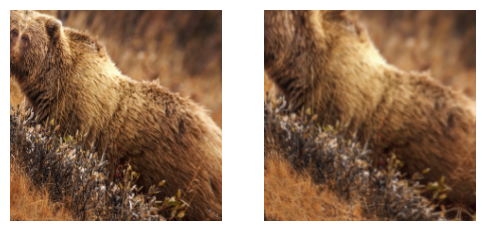

In [46]:
#hide_input
#id interpolations
#caption A comparison of fastai's data augmentation strategy (left) and the traditional approach (right).
dblock1 = DataBlock(blocks=(ImageBlock(), CategoryBlock()),
                   get_y=parent_label,
                   item_tfms=Resize(460))
# Place an image in the 'images/grizzly.jpg' subfolder where this notebook is located before running this
dls1 = dblock1.dataloaders([(Path.cwd()/'images'/'grizzly.jpg')]*100, bs=8)
dls1.train.get_idxs = lambda: Inf.ones
x,y = dls1.valid.one_batch()
_,axs = subplots(1, 2)

x1 = TensorImage(x.clone())
x1 = x1.affine_coord(sz=224)
x1 = x1.rotate(draw=30, p=1.)
x1 = x1.zoom(draw=1.2, p=1.)
x1 = x1.warp(draw_x=-0.2, draw_y=0.2, p=1.)

tfms = setup_aug_tfms([Rotate(draw=30, p=1, size=224), Zoom(draw=1.2, p=1., size=224),
                       Warp(draw_x=-0.2, draw_y=0.2, p=1., size=224)])
x = Pipeline(tfms)(x)
#x.affine_coord(coord_tfm=coord_tfm, sz=size, mode=mode, pad_mode=pad_mode)
TensorImage(x[0]).show(ctx=axs[0])
TensorImage(x1[0]).show(ctx=axs[1]);

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Вы можете видеть, что изображение справа менее четкое и имеет артефакты отражающей обрезки в нижнем левом углу; также трава в верхнем левом углу полностью исчезла. На практике мы обнаруживаем, что использование предварительного изменения размера значительно улучшает точность моделей и часто также приводит к увеличению скорости.

Библиотека fastai также предоставляет простые способы проверить, правильно ли выглядят ваши данные перед обучением модели, что является крайне важным шагом. Мы рассмотрим это далее.

### Проверка и отладка DataBlock

Мы никогда не можем просто предполагать, что наш код работает идеально. Написание `DataBlock` похоже на создание чертежа. Вы получите сообщение об ошибке, если у вас есть синтаксическая ошибка где-то в коде, но у вас нет гарантии, что ваш шаблон будет работать с вашим источником данных так, как вы намеревались. Поэтому перед обучением модели вы всегда должны проверять свои данные. Вы можете сделать это, используя метод `show_batch`:

In [ ]:
dls.show_batch(nrows=1, ncols=3)

Посмотрите на каждое изображение и проверьте, что каждое из них, кажется, имеет правильную метку для этой породы питомца. Часто ученые-данные работают с данными, с которыми они не так знакомы, как эксперты в области: например, я на самом деле не знаю, что представляют собой многие из этих пород питомцев. Поскольку я не являюсь экспертом по породам питомцев, я бы в этот момент использовал Google Images, чтобы поискать несколько из этих пород и убедиться, что изображения выглядят похоже на то, что я вижу в этом выводе.

Если вы допустили ошибку при создании вашего `DataBlock`, очень вероятно, что вы не увидите ее до этого шага. Чтобы отладить это, мы рекомендуем использовать метод `summary`. Он попытается создать партию из источника, который вы ему предоставите, с множеством деталей. Также, если он не удастся, вы увидите точно, на каком этапе произошла ошибка, и библиотека попытается дать вам некоторую помощь. Например, одной из распространенных ошибок является забывание использовать трансформацию `Resize`, в результате чего вы получаете изображения разных размеров и не можете объединить их в партию. Вот как будет выглядеть сводка в этом случае (обратите внимание, что точный текст мог измениться с момента написания, но это даст вам представление):

In [ ]:
#hide_output
pets1 = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(seed=42),
                 get_y=using_attr(RegexLabeller(r'(.+)_\d+.jpg$'), 'name'))
pets1.summary(path/"images")

```
Setting-up type transforms pipelines
Collecting items from /home/sgugger/.fastai/data/oxford-iiit-pet/images
Found 7390 items
2 datasets of sizes 5912,1478
Setting up Pipeline: PILBase.create
Setting up Pipeline: partial -> Categorize

Building one sample
  Pipeline: PILBase.create
    starting from
      /home/sgugger/.fastai/data/oxford-iiit-pet/images/american_bulldog_83.jpg
    applying PILBase.create gives
      PILImage mode=RGB size=375x500
  Pipeline: partial -> Categorize
    starting from
      /home/sgugger/.fastai/data/oxford-iiit-pet/images/american_bulldog_83.jpg
    applying partial gives
      american_bulldog
    applying Categorize gives
      TensorCategory(12)

Final sample: (PILImage mode=RGB size=375x500, TensorCategory(12))

Setting up after_item: Pipeline: ToTensor
Setting up before_batch: Pipeline:
Setting up after_batch: Pipeline: IntToFloatTensor

Building one batch
Applying item_tfms to the first sample:
  Pipeline: ToTensor
    starting from
      (PILImage mode=RGB size=375x500, TensorCategory(12))
    applying ToTensor gives
      (TensorImage of size 3x500x375, TensorCategory(12))

Adding the next 3 samples

No before_batch transform to apply

Collating items in a batch
Error! It's not possible to collate your items in a batch
Could not collate the 0-th members of your tuples because got the following
shapes:
torch.Size([3, 500, 375]),torch.Size([3, 375, 500]),torch.Size([3, 333, 500]),
torch.Size([3, 375, 500])
```

Вы можете точно увидеть, как мы собрали данные и разделили их, как мы перешли от имени файла к *образцу* (кортеж (изображение, категория)), затем какие трансформации элементов были применены и как не удалось объединить эти образцы в партию (из-за различных форм).

Как только вы думаете, что ваши данные выглядят правильно, мы обычно рекомендуем следующим шагом использовать их для обучения простой модели. Мы часто видим, как люди откладывают обучение фактической модели слишком надолго. В результате они не узнают, каковы их базовые результаты. Возможно, вашей задаче не требуется много сложной специфической для области инженерии. Или, возможно, данные вообще не обучают модель. Это то, что вы хотите узнать как можно скорее. Для этого первоначального теста мы будем использовать ту же простую модель, которую использовали в \<\<chapter_intro\>\>:

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(2)

Как мы уже кратко обсуждали ранее, таблица, отображаемая при обучении модели, показывает нам результаты после каждой эпохи обучения. Помните, что эпоха — это один полный проход по всем изображениям в данных. Отображаемые столбцы — это средняя потеря по элементам обучающего набора, потеря на валидационном наборе и любые метрики, которые мы запросили — в данном случае, уровень ошибок.

Помните, что *потеря* — это любая функция, которую мы решили использовать для оптимизации параметров нашей модели. Но мы на самом деле не сказали fastai, какую функцию потерь мы хотим использовать. Так что же он делает? fastai, как правило, пытается выбрать подходящую функцию потерь в зависимости от того, какой тип данных и модели вы используете. В данном случае у нас есть данные изображений и категориальный результат, поэтому fastai по умолчанию использует *потерю кросс-энтропии*.

## Потеря Кросс-Энтропии

*Потеря кросс-энтропии* — это функция потерь, которая похожа на ту, которую мы использовали в предыдущей главе, но (как мы увидим) имеет два преимущества:

- Она работает даже тогда, когда наша зависимая переменная имеет более двух категорий.
- Она приводит к более быстрому и надежному обучению.

Чтобы понять, как работает потеря кросс-энтропии для зависимых переменных с более чем двумя категориями, нам сначала нужно понять, как выглядят фактические данные и активации, которые видит функция потерь.

### Просмотр активаций и меток

Давайте посмотрим на активации нашей модели. Чтобы получить партию реальных данных из наших `DataLoaders`, мы можем использовать метод `one_batch`:

In [ ]:
x,y = dls.one_batch()

Как вы видите, это возвращает зависимые и независимые переменные в виде мини-партии. Давайте посмотрим, что на самом деле содержится в нашей зависимой переменной:

In [ ]:
y

Наш размер партии составляет 64, поэтому в этом тензоре у нас 64 строки. Каждая строка — это одно целое число от 0 до 36, представляющее наши 37 возможных пород питомцев. Мы можем просмотреть предсказания (то есть активации последнего слоя нашей нейронной сети), используя `Learner.get_preds`. Эта функция принимает либо индекс набора данных (0 для обучающего и 1 для валидационного), либо итератор партий. Таким образом, мы можем передать ей простой список с нашей партией, чтобы получить наши предсказания. По умолчанию она возвращает предсказания и цели, но поскольку у нас уже есть цели, мы можем эффективно игнорировать их, присвоив специальной переменной `_`:

In [ ]:
preds,_ = learn.get_preds(dl=[(x,y)])
preds[0]

Фактические предсказания — это 37 вероятностей между 0 и 1, которые в сумме дают 1:

In [ ]:
len(preds[0]),preds[0].sum()

Чтобы преобразовать активации нашей модели в такие предсказания, мы использовали функцию активации, называемую *softmax*.

### Softmax

В нашей модели классификации мы используем функцию активации softmax на последнем слое, чтобы гарантировать, что активации находятся в пределах от 0 до 1 и в сумме дают 1.

Softmax похожа на сигмоидную функцию, которую мы видели ранее. Напоминаем, что сигмоид выглядит так:

In [ ]:
plot_function(torch.sigmoid, min=-4,max=4)

Мы можем применить эту функцию к одному столбцу активаций из нейронной сети и получить обратно столбец чисел от 0 до 1, так что это очень полезная функция активации для нашего последнего слоя.

Теперь подумайте о том, что происходит, если мы хотим иметь больше категорий в нашей цели (например, наши 37 пород питомцев). Это означает, что нам нужно больше активаций, чем просто один столбец: нам нужна активация *для каждой категории*. Мы можем создать, например, нейронную сеть, которая предсказывает 3 и 7, и которая возвращает две активации, по одной для каждого класса — это будет хорошим первым шагом к созданию более общего подхода. Давайте просто используем случайные числа со стандартным отклонением 2 (поэтому мы умножаем `randn` на 2) для этого примера, предполагая, что у нас есть 6 изображений и 2 возможные категории (где первый столбец представляет 3, а второй — 7):

In [ ]:
#hide
torch.random.manual_seed(42);

In [ ]:
acts = torch.randn((6,2))*2
acts

Мы не можем просто взять сигмоиду от этого напрямую, поскольку мы не получаем строки, которые в сумме дают 1 (т.е. мы хотим, чтобы вероятность быть 3 плюс вероятность быть 7 в сумме давали 1):

In [ ]:
acts.sigmoid()

В \<\<chapter_mnist_basics\>\> наша нейронная сеть создала одну активацию на изображение, которую мы пропустили через функцию `sigmoid`. Эта единственная активация представляла уверенность модели в том, что входное значение — это 3. Двоичные задачи являются особым случаем задач классификации, поскольку цель может рассматриваться как одно булево значение, как мы делали в `mnist_loss`. Но двоичные задачи также можно рассматривать в контексте более общей группы классификаторов с любым количеством категорий: в данном случае у нас есть две категории. Как мы видели в классификаторе медведей, наша нейронная сеть будет возвращать одну активацию на категорию.

Так что же на самом деле означают эти активации в двоичном случае? Одна пара активаций просто указывает на *относительную* уверенность в том, что входное значение является 3 по сравнению с тем, что оно является 7. Общие значения, будь они высокими или низкими, не имеют значения — важно только, какое из них выше и на сколько.

Мы бы ожидали, что, поскольку это просто другой способ представления одной и той же задачи, мы сможем использовать `sigmoid` напрямую на версии нашей нейронной сети с двумя активациями. И действительно, мы можем! Мы можем просто взять *разницу* между активациями нейронной сети, потому что это отражает, насколько мы более уверены в том, что входное значение является 3, чем 7, а затем взять сигмоиду от этого:

In [ ]:
(acts[:,0]-acts[:,1]).sigmoid()

Второй столбец (вероятность того, что это 7) будет просто равен этому значению, вычтенному из 1. Теперь нам нужен способ сделать все это, который также работает для более чем двух столбцов. Оказывается, что эта функция, называемая `softmax`, именно такая:

```python
def softmax(x): return exp(x) / exp(x).sum(dim=1, keepdim=True)
```

> терминология: Экспоненциальная функция (exp): Буквально определена как `e**x`, где `e` — это специальное число, приблизительно равное 2.718. Это обратная функция натурального логарифма. Обратите внимание, что `exp` всегда положительна и увеличивается _очень_ быстро!

Давайте проверим, что `softmax` возвращает те же значения, что и `sigmoid` для первого столбца, а также те значения, вычтенные из 1, для второго столбца:

In [ ]:
sm_acts = torch.softmax(acts, dim=1)
sm_acts

`softmax` является многоклассовым эквивалентом `sigmoid` — его необходимо использовать всякий раз, когда у нас более двух категорий, и вероятности категорий должны суммироваться до 1. Мы часто используем его даже при наличии всего лишь двух категорий, чтобы сделать всё немного более последовательным. Мы могли бы создать другие функции, которые обладают свойствами, что все активации находятся в диапазоне от 0 до 1 и суммируются до 1; однако ни одна другая функция не имеет такой же связи с функцией `sigmoid`, которая, как мы видели, является гладкой и симметричной. Также мы вскоре увидим, что функция `softmax` хорошо работает в связке с функцией потерь, которую мы рассмотрим в следующем разделе.

Если у нас есть три активации на выходе, например, в нашем классификаторе медведей, то вычисление `softmax` для одного изображения медведя будет выглядеть примерно так \<\<bear_softmax\>\>.

<img alt="Bear softmax example" width="280" id="bear_softmax" caption="Example of softmax on the bear classifier" src="https://github.com/Wansmer/fastbook/blob/ru/images/att_00062.png?raw=1">

Что делает эта функция на практике? Использование экспоненты гарантирует, что все наши числа положительные, а деление на сумму обеспечивает, что у нас будет набор чисел, которые в сумме дают 1. Экспонента также обладает приятным свойством: если одно из чисел в наших активациях `x` немного больше остальных, экспонента усилит это (поскольку она растет, ну... экспоненциально), что означает, что в `softmax` это число будет ближе к 1.

Интуитивно, функция `softmax` *действительно* стремится выбрать один класс среди других, поэтому она идеальна для обучения классификатора, когда мы знаем, что каждое изображение имеет определенную метку. (Обратите внимание, что это может быть менее идеальным во время вывода, так как вы можете захотеть, чтобы ваша модель иногда сообщала вам, что она не распознает ни один из классов, которые она видела во время обучения, и не выбирала класс только потому, что у него немного больший балл активации. В этом случае может быть лучше обучить модель, используя несколько бинарных выходных колонок, каждая из которых использует активацию `sigmoid`.)

`Softmax` является первой частью функции потерь кросс-энтропии — второй частью является логарифмическая вероятность.

### Логарифмическое правдоподобие

Когда мы рассчитывали потерю для нашего примера MNIST в предыдущей главе, мы использовали:

```python
def mnist_loss(inputs, targets):
    inputs = inputs.sigmoid()
    return torch.where(targets==1, 1-inputs, inputs).mean()
```

Так же, как мы перешли от сигмоиды к softmax, нам нужно расширить функцию потерь, чтобы она работала не только с бинарной классификацией — она должна уметь классифицировать любое количество категорий (в данном случае у нас 37 категорий). Наши активации после softmax находятся в пределах от 0 до 1 и в сумме дают 1 для каждой строки в партии предсказаний. Наши цели — это целые числа от 0 до 36. Более того, потеря кросс-энтропии обобщает нашу потерю бинарной классификации и позволяет иметь более одной правильной метки на пример (что называется многометочной классификацией, которую мы обсудим в главе 6).

В бинарном случае мы использовали `torch.where`, чтобы выбрать между `inputs` и `1-inputs`. Когда мы рассматриваем бинарную классификацию как общую задачу классификации с двумя категориями, на самом деле это становится даже проще, потому что (как мы видели в предыдущем разделе) у нас теперь есть два столбца, содержащие эквиваленты `inputs` и `1-inputs`. Поскольку на каждый пример есть только одна правильная метка, все, что нам нужно сделать, это выбрать соответствующий столбец (вместо того, чтобы умножать несколько вероятностей). Давайте попробуем реализовать это в PyTorch. Для нашего синтетического примера с 3 и 7, предположим, что это наши метки:

In [ ]:
targ = tensor([0,1,0,1,1,0])

и это активации softmax:

In [ ]:
sm_acts

Затем для каждого элемента `targ` мы можем использовать это, чтобы выбрать соответствующий столбец из `sm_acts`, используя индексацию тензора, вот так:

In [ ]:
idx = range(6)
sm_acts[idx, targ]

Чтобы точно увидеть, что здесь происходит, давайте соберем все столбцы вместе в таблицу. Здесь первые два столбца — это наши активации, затем у нас есть цели и индекс строки. Мы объясним последний столбец, `result`, ниже:

In [ ]:
#hide_input
from IPython.display import HTML
df = pd.DataFrame(sm_acts, columns=["3","7"])
df['targ'] = targ
df['idx'] = idx
df['result'] = sm_acts[range(6), targ]
t = df.style.hide_index()
#To have html code compatible with our script
html = t._repr_html_().split('</style>')[1]
html = re.sub(r'<table id="([^"]+)"\s*>', r'<table >', html)
display(HTML(html))

Смотря на эту таблицу, вы можете увидеть, что столбец `result` можно вычислить, используя столбцы `targ` и `idx` в качестве индексов для двумерной матрицы, содержащей столбцы `3` и `7`. Именно это и делает `sm_acts[idx, targ]`. Действительно интересная вещь здесь заключается в том, что это работает так же хорошо и с более чем двумя столбцами. Чтобы увидеть это, рассмотрим, что произойдет, если мы добавим столбец активации для каждой цифры (от 0 до 9), и тогда `targ` будет содержать число от 0 до 9.

PyTorch предоставляет функцию, которая делает именно то же самое, что и `sm_acts[range(n), targ]` (за исключением того, что она берет отрицательное значение, потому что при последующем применении логарифма у нас будут отрицательные числа), называемую `nll_loss` (*NLL* означает *отрицательное логарифмическое правдоподобие*):

In [ ]:
-sm_acts[idx, targ]

In [ ]:
F.nll_loss(sm_acts, targ, reduction='none')

Несмотря на свое название, эта функция PyTorch не берет логарифм. Мы увидим, почему в следующем разделе, но сначала давайте рассмотрим, почему взятие логарифма может быть полезным.

> предупреждение: Запутывающее название, будьте осторожны: nll в `nll_loss` означает "отрицательное логарифмическое правдоподобие", но на самом деле он вообще не берет логарифм! Он предполагает, что вы _уже_ взяли логарифм. В PyTorch есть функция, называемая `log_softmax`, которая сочетает `log` и `softmax` быстрым и точным способом. `nll_loss` предназначен для использования после `log_softmax`.

#### Взятие логарифма

Напомним, что потеря кросс-энтропии может включать умножение множества чисел. Умножение большого количества отрицательных чисел может вызвать проблемы, такие как [числовой переполнение](https://en.wikipedia.org/wiki/Arithmetic_underflow) в компьютерах. Поэтому мы хотим преобразовать эти вероятности в более крупные значения, чтобы мы могли выполнять математические операции с ними. Существует математическая функция, которая делает именно это: *логарифм* (доступен как `torch.log`). Он не определен для чисел меньше 0 и выглядит так между 0 и 1:

In [ ]:
plot_function(torch.log, min=0,max=1, ty='log(x)', tx='x')

Кроме того, мы хотим убедиться, что наша модель способна обнаруживать различия между маленькими числами. Например, рассмотрим вероятности 0.01 и 0.001. Действительно, эти числа очень близки друг к другу, но в другом смысле 0.01 в 10 раз более уверенно, чем 0.001. Взяв логарифм наших вероятностей, мы предотвращаем игнорирование этих важных различий.

Звучит знакомо слово "логарифм"? Функция логарифма имеет эту идентичность:

```
y = b**a
a = log(y,b)
```

В этом случае мы предполагаем, что `log(y,b)` возвращает *логарифм y по основанию b*. Однако в PyTorch на самом деле не определяют `log` таким образом: `log` в Python использует специальное число `e` (2.718...) в качестве основания.

Возможно, вы не думали о логарифмах последние 20 лет или около того. Но это математическая идея, которая будет действительно критична для многих вещей в глубоком обучении, так что сейчас будет отличное время, чтобы освежить свою память. Ключевое, что нужно знать о логарифмах, — это эта связь:

    log(a*b) = log(a) + log(b)

Когда мы видим это в таком формате, это выглядит немного скучно; но подумайте, что это действительно означает. Это означает, что логарифмы увеличиваются линейно, когда основной сигнал увеличивается экспоненциально или мультипликативно. Это используется, например, в шкале Рихтера для оценки силы землетрясений и в шкале дБ для уровней шума. Это также часто используется на финансовых графиках, где мы хотим более четко показать темпы сложного роста. Компьютерные ученые любят использовать логарифмы, потому что это означает, что умножение, которое может создавать действительно большие и действительно маленькие числа, может быть заменено сложением, что гораздо менее вероятно приведет к масштабам, которые трудно обрабатывать нашим компьютерам.

Обратите внимание, что логарифм числа стремится к отрицательной бесконечности, когда число стремится к нулю. В нашем случае, поскольку результат отражает предсказанную вероятность правильной метки, мы хотим, чтобы наша функция потерь возвращала небольшое значение, когда предсказание "хорошее" (ближе к 1), и большое значение, когда предсказание "плохое" (ближе к 0). Мы можем достичь этого, взяв отрицательное значение логарифма:

In [ ]:
plot_function(lambda x: -1*torch.log(x), min=0,max=1, tx='x', ty='- log(x)', title = 'Log Loss when true label = 1')

> s: Логарифмы нравятся не только компьютерным ученым! До появления компьютеров инженеры и ученые использовали специальную линейку, называемую "логарифмической линейкой", которая выполняла умножение, складывая логарифмы. Логарифмы широко используются в физике для умножения очень больших или очень маленьких чисел, а также во многих других областях.

Давайте обновим нашу предыдущую таблицу, добавив дополнительный столбец `loss`, чтобы отразить эту функцию потерь:

In [ ]:
#hide_input
from IPython.display import HTML
df['loss'] = -torch.log(tensor(df['result']))
t = df.style.hide_index()
#To have html code compatible with our script
html = t._repr_html_().split('</style>')[1]
html = re.sub(r'<table id="([^"]+)"\s*>', r'<table >', html)
display(HTML(html))

Обратите внимание, что потеря очень велика в третьем и четвертом рядах, где предсказания уверенные и неверные, или, другими словами, имеют высокие вероятности для неправильного класса. Одно из преимуществ использования логарифма для расчета потерь заключается в том, что наша функция потерь штрафует предсказания, которые одновременно уверенные и неверные. Этот вид штрафа хорошо работает на практике, способствуя более эффективному обучению модели.

> s: Существуют и другие функции потерь, такие как [focal loss](https://arxiv.org/pdf/1708.02002.pdf), которые позволяют контролировать этот штраф с помощью параметра. Мы не обсуждаем эту функцию потерь в этой книге.

Мы рассчитываем потерю на основе столбца, содержащего правильную метку. Поскольку на каждый пример есть только один "правильный" ответ, нам не нужно учитывать другие столбцы, потому что по определению softmax они в сумме дают 1 минус активация, соответствующая правильной метке. Пока столбцы активаций в сумме дают 1 (как это будет, если мы используем softmax), у нас будет функция потерь, которая показывает, насколько хорошо мы предсказываем каждую цифру. Следовательно, максимизация активации для правильной метки должна означать, что мы также уменьшаем активации оставшихся столбцов.

### Отрицательное логарифмическое правдоподобие

Взятие среднего значения отрицательного логарифма наших вероятностей (взятие среднего значения столбца `loss` в нашей таблице) дает нам *отрицательное логарифмическое правдоподобие*, которое является другим названием для потерь кросс-энтропии. Напомним, что `nll_loss` в PyTorch предполагает, что вы уже взяли логарифм softmax, поэтому он на самом деле не выполняет логарифм за вас.

Когда мы сначала берем softmax, а затем логарифмическое правдоподобие от этого, эта комбинация называется *потерей кросс-энтропии*. В PyTorch это доступно как `nn.CrossEntropyLoss` (которая на практике фактически выполняет `log_softmax`, а затем `nll_loss`):

In [ ]:
loss_func = nn.CrossEntropyLoss()

Как вы видите, это класс. Создание экземпляра этого класса дает вам объект, который ведет себя как функция:

In [ ]:
loss_func(acts, targ)

Все функции потерь в PyTorch предоставляются в двух формах: в виде класса, только что показанного выше, и также в простой функциональной форме, доступной в пространстве имен `F`:

In [ ]:
F.cross_entropy(acts, targ)

Обе формы работают хорошо и могут использоваться в любой ситуации. Мы заметили, что большинство людей склоняются к использованию версии класса, и она чаще используется в официальной документации и примерах PyTorch, поэтому мы тоже будем использовать ее.

По умолчанию функции потерь PyTorch берут среднее значение потерь для всех элементов. Вы можете использовать `reduction='none'`, чтобы отключить это:

In [ ]:
nn.CrossEntropyLoss(reduction='none')(acts, targ)

Вы заметите, что эти значения точно совпадают со столбцом `loss` в нашей таблице.

> s: Интересная особенность потерь кросс-энтропии проявляется, когда мы рассматриваем ее градиент. Градиент `cross_entropy(a,b)` равен просто `softmax(a) - b`. Поскольку `softmax(a)` — это просто финальная активация модели, это означает, что градиент пропорционален разнице между предсказанием и целью. Это то же самое, что и среднеквадратичная ошибка в регрессии (при условии, что нет финальной функции активации, такой как та, что добавляется `y_range`), поскольку градиент `(a-b)**2` равен `2*(a-b)`. Поскольку градиент линейный, это означает, что мы не увидим резких скачков или экспоненциальных увеличений градиентов, что должно привести к более плавному обучению моделей.

Теперь мы рассмотрели все элементы, скрытые за нашей функцией потерь. Но хотя это дает нам число, отражающее, насколько хорошо (или плохо) работает наша модель, это не помогает нам понять, действительно ли она хороша. Давайте теперь рассмотрим несколько способов интерпретировать предсказания нашей модели.

## Интерпретация модели

Очень трудно интерпретировать функции потерь напрямую, потому что они предназначены для того, чтобы компьютеры могли их дифференцировать и оптимизировать, а не для того, чтобы люди могли их понять. Вот почему у нас есть метрики. Они не используются в процессе оптимизации, а просто помогают нам, бедным людям, понять, что происходит. В данном случае наша точность уже выглядит довольно хорошо! Так где же мы совершаем ошибки?

Мы видели в \<\<chapter_intro\>\>, что можем использовать матрицу путаницы, чтобы увидеть, где наша модель работает хорошо, а где плохо:

In [ ]:
#width 600
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(12,12), dpi=60)

Ой, в этом случае матрица путаницы очень трудно читается. У нас 37 различных пород питомцев, что означает, что у нас есть 37×37 записей в этой гигантской матрице! Вместо этого мы можем использовать метод `most_confused`, который просто показывает нам ячейки матрицы путаницы с наибольшим количеством неверных предсказаний (здесь — с 5 и более):

In [ ]:
interp.most_confused(min_val=5)

Поскольку мы не являемся экспертами по породам питомцев, нам трудно понять, отражают ли эти ошибки категорий реальные трудности в распознавании пород. Поэтому снова обращаемся к Google. Небольшой поиск показывает, что наиболее распространенные ошибки категорий, представленные здесь, на самом деле являются различиями между породами, по которым даже эксперты-разведенцы иногда не согласны. Это дает нам некоторое утешение, что мы на правильном пути.

У нас, похоже, есть хорошая базовая линия. Что мы можем сделать сейчас, чтобы сделать ее еще лучше?

## Улучшаем нашу модель

Теперь мы рассмотрим ряд техник для улучшения обучения нашей модели и повышения ее качества. При этом мы немного подробнее объясним, что такое трансферное обучение и как лучше всего настроить нашу предобученную модель, не нарушая предобученные веса.

Первое, что нам нужно установить при обучении модели, — это скорость обучения. Мы видели в предыдущей главе, что она должна быть оптимальной для максимально эффективного обучения, так как же выбрать хорошую? fastai предоставляет инструмент для этого.

### Поиск скорости обучения

Одним из самых важных аспектов при обучении модели является правильный выбор скорости обучения (learning rate). Если наша скорость обучения слишком низка, обучение модели может занять много эпох (epochs). Это не только тратит время, но также может привести к проблемам с переобучением (overfitting), поскольку каждый раз, когда мы проходим полный цикл по данным, мы даем модели возможность запомнить их.

Так что давайте просто сделаем нашу скорость обучения очень высокой, верно? Конечно, давайте попробуем и посмотрим, что произойдет:

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(1, base_lr=0.1)

Это выглядит не очень хорошо. Вот что произошло. Оптимизатор (optimizer) сделал шаг в правильном направлении, но он шагнул так далеко, что полностью перескочил минимум потерь (minimum loss). Повторяя это несколько раз, он уходит все дальше и дальше, а не ближе и ближе!

Что нам делать, чтобы найти идеальную скорость обучения — не слишком высокую и не слишком низкую? В 2015 году исследователь Лесли Смит (Leslie Smith) предложил блестящую идею, названную *поиском скорости обучения* (learning rate finder). Его идея заключалась в том, чтобы начать с очень-очень низкой скорости обучения, такой маленькой, что мы никогда не ожидали бы, что она будет слишком большой для обработки. Мы используем это для одного мини-батча (mini-batch), находим, каковы потери (loss) после этого, а затем увеличиваем скорость обучения на некоторый процент (например, удваиваем ее каждый раз). Затем мы делаем еще один мини-батч, отслеживаем потери и снова удваиваем скорость обучения. Мы продолжаем делать это, пока потери не начнут ухудшаться, вместо того чтобы улучшаться. Это тот момент, когда мы знаем, что зашли слишком далеко. Затем мы выбираем скорость обучения немного ниже этого значения. Наш совет — выбрать либо:

- Один порядок величины меньше, чем там, где были достигнуты минимальные потери (т.е. минимум, деленный на 10)
- Последнюю точку, где потери явно уменьшались

Поиск скорости обучения вычисляет эти точки на кривой, чтобы помочь вам. Оба этих правила обычно дают примерно одно и то же значение. В первой главе мы не указывали скорость обучения, используя значение по умолчанию из библиотеки fastai (которое равно 1e-3):

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
lr_min,lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))

In [ ]:
print(f"Minimum/10: {lr_min:.2e}, steepest point: {lr_steep:.2e}")

На этом графике мы видим, что в диапазоне от 1e-6 до 1e-3 ничего не происходит, и модель не обучается. Затем потери начинают уменьшаться, пока не достигают минимума, а затем снова увеличиваются. Мы не хотим, чтобы скорость обучения была больше 1e-1, так как это приведет к расходимости обучения, как в предыдущем случае (вы можете попробовать сами), но 1e-1 уже слишком высока: на этом этапе мы покинули период, когда потери стабильно уменьшались.

На этом графике скорости обучения кажется, что скорость обучения около 3e-3 будет подходящей, так что давайте выберем это:

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(2, base_lr=3e-3)

> Примечание: Логарифмическая шкала: График поиска скорости обучения имеет логарифмическую шкалу, поэтому средняя точка между 1e-3 и 1e-2 находится между 3e-3 и 4e-3. Это связано с тем, что нас в первую очередь интересует порядок величины скорости обучения.

Интересно, что поиск скорости обучения был открыт только в 2015 году, в то время как нейронные сети разрабатываются с 1950-х годов. На протяжении этого времени нахождение хорошей скорости обучения было, возможно, самым важным и сложным вопросом для практиков. Решение не требует никаких сложных математических расчетов, гигантских вычислительных ресурсов, огромных наборов данных или чего-либо еще, что сделало бы его недоступным для любого любознательного исследователя. Более того, Лесли Смит (Leslie Smith) не работал в какой-то эксклюзивной лаборатории в Силиконовой долине, а был морским исследователем. Все это говорит о том, что прорывные работы в области глубокого обучения абсолютно не требуют доступа к огромным ресурсам, элитным командам или сложным математическим идеям. Все еще предстоит проделать много работы, которая требует лишь немного здравого смысла, креативности и настойчивости.

Теперь, когда у нас есть хорошая скорость обучения для обучения нашей модели, давайте рассмотрим, как мы можем донастроить веса (weights) предобученной модели (pretrained model).

### Размораживание и перенос обучения (Transfer Learning)

Мы кратко обсуждали в \<\<chapter_intro\>\>, как работает перенос обучения (transfer learning). Мы увидели, что основная идея заключается в том, что предобученная модель, обученная потенциально на миллионах данных (таких как ImageNet), донастраивается для какой-то другой задачи. Но что это на самом деле означает?

Теперь мы знаем, что сверточная нейронная сеть (convolutional neural network) состоит из множества линейных слоев с нелинейной функцией активации между каждой парой, за которыми следуют один или несколько финальных линейных слоев с функцией активации, такой как softmax, в самом конце. Финальный линейный слой использует матрицу с достаточным количеством столбцов, чтобы размер выходных данных соответствовал количеству классов в нашей модели (предполагая, что мы занимаемся классификацией).

Этот финальный линейный слой вряд ли будет полезен для нас, когда мы донастраиваем в контексте переноса обучения, потому что он специально предназначен для классификации категорий в исходном наборе данных для предобучения. Поэтому, когда мы занимаемся переносом обучения, мы удаляем его, выбрасываем и заменяем новым линейным слоем с правильным количеством выходов для нашей желаемой задачи (в данном случае будет 37 активаций).

Этот вновь добавленный линейный слой будет иметь совершенно случайные веса. Следовательно, наша модель до донастройки будет иметь совершенно случайные выходные данные. Но это не означает, что она является совершенно случайной моделью! Все слои перед последним были тщательно обучены, чтобы хорошо справляться с задачами классификации изображений в целом. Как мы видели на изображениях из статьи [Зейлера и Фергюсона](https://arxiv.org/pdf/1311.2901.pdf) в \<\<chapter_intro\>\> (см. \<\<img_layer1\>\> по \<\<img_layer4\>\>), первые несколько слоев кодируют очень общие концепции, такие как нахождение градиентов и краев, а более поздние слои кодируют концепции, которые все еще очень полезны для нас, такие как нахождение глаз и шерсти.

Мы хотим обучить модель таким образом, чтобы она могла запомнить все эти общие полезные идеи из предобученной модели, использовать их для решения нашей конкретной задачи (классификация пород домашних животных) и только при необходимости корректировать их для специфики нашей задачи.

Наша задача при донастройке заключается в том, чтобы заменить случайные веса в добавленных линейных слоях на веса, которые правильно достигают нашей желаемой задачи (классификация пород домашних животных), не нарушая тщательно предобученные веса и другие слои. На самом деле существует очень простой трюк, который позволяет это сделать: сказать оптимизатору обновлять только веса в этих случайно добавленных финальных слоях. Не изменяйте веса в остальной части нейронной сети вообще. Это называется *замораживанием* (freezing) этих предобученных слоев.

Когда мы создаем модель из предобученной сети, fastai автоматически замораживает все предобученные слои за нас. Когда мы вызываем метод `fine_tune`, fastai выполняет две вещи:

- Обучает случайно добавленные слои в течение одной эпохи, при этом все остальные слои заморожены.
- Размораживает все слои и обучает их все в течение запрашиваемого количества эпох.

Хотя это разумный подход по умолчанию, вероятно, что для вашего конкретного набора данных вы можете получить лучшие результаты, делая что-то немного иначе. Метод `fine_tune` имеет несколько параметров, которые вы можете использовать для изменения его поведения, но, возможно, будет проще просто вызвать основные методы напрямую, если вы хотите получить какое-то индивидуальное поведение. Помните, что вы можете увидеть исходный код метода, используя следующий синтаксис:

    learn.fine_tune??

Итак, давайте попробуем сделать это вручную. Прежде всего, мы обучим случайно добавленные слои в течение трех эпох, используя `fit_one_cycle`. Как упоминалось в \<\<chapter_intro\>\>, `fit_one_cycle` — это рекомендуемый способ обучения моделей без использования `fine_tune`. Мы увидим, почему позже в книге; вкратце, то, что делает `fit_one_cycle`, — это начинает обучение с низкой скорости обучения, постепенно увеличивает ее в первой части обучения, а затем снова постепенно уменьшает в последней части обучения.

In [ ]:
learn.fine_tune??

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fit_one_cycle(3, 3e-3)

Затем мы разморозим модель:

In [ ]:
learn.unfreeze()

и снова запустим `lr_find`, потому что наличие большего количества слоев для обучения и весов, которые уже были обучены в течение трех эпох, означает, что ранее найденная скорость обучения больше не подходит:

In [ ]:
learn.lr_find()

Обратите внимание, что график немного отличается от того, когда у нас были случайные веса: у нас нет резкого спуска, который указывает на то, что модель обучается. Это связано с тем, что наша модель уже была обучена. Здесь у нас есть несколько плоская область перед резким увеличением, и мы должны выбрать точку хорошо до этого резкого увеличения — например, 1e-5. Точка с максимальным градиентом не является тем, что мы ищем здесь, и ее следует игнорировать.

Давайте обучим модель на подходящей скорости обучения:

In [ ]:
learn.fit_one_cycle(6, lr_max=1e-5)

Это немного улучшило нашу модель, но мы можем сделать больше. Самые глубокие слои нашей предобученной модели, возможно, не нуждаются в такой высокой скорости обучения, как последние, поэтому, вероятно, нам следует использовать разные скорости обучения для них — это известно как использование *дискриминационных скоростей обучения* (discriminative learning rates).

### Дискриминационные Скорости Обучения (Discriminative Learning Rates)

Даже после того, как мы разморозили модель, мы все еще очень заботимся о качестве этих предобученных весов. Мы не ожидаем, что лучшая скорость обучения для этих предобученных параметров будет такой же высокой, как для случайно добавленных параметров, даже после того, как мы настроили эти случайно добавленные параметры в течение нескольких эпох. Помните, что предобученные веса были обучены в течение сотен эпох на миллионах изображений.

Кроме того, вы помните изображения, которые мы видели в \<\<chapter_intro\>\>, показывающие, что каждый слой изучает? Первый слой изучает очень простые основы, такие как детекторы краев и градиентов; они, вероятно, будут столь же полезны для почти любой задачи. Более поздние слои изучают гораздо более сложные концепции, такие как "глаз" и "закат", которые могут вообще не быть полезными для вашей задачи (например, вы классифицируете модели автомобилей). Поэтому имеет смысл позволить более поздним слоям донастраиваться быстрее, чем более ранним слоям.

Таким образом, стандартный подход fastai заключается в использовании дискриминационных скоростей обучения. Этот подход был изначально разработан в методе ULMFiT для переноса обучения в NLP, который мы представим в \<\<chapter_nlp\>\>. Как и многие хорошие идеи в глубоких нейронных сетях, он чрезвычайно прост: используйте более низкую скорость обучения для ранних слоев нейронной сети и более высокую скорость обучения для более поздних слоев (особенно для случайно добавленных слоев). Эта идея основана на выводах, разработанных [Джейсонем Йосински](https://arxiv.org/abs/1411.1792), который показал в 2014 году, что при переносе обучения разные слои нейронной сети должны обучаться с разной скоростью, как показано в \<\<yosinski\>\>.

<img alt="Impact of different layers and training methods on transfer learning (Yosinski)" width="680" caption="Impact of different layers and training methods on transfer learning (courtesy of Jason Yosinski et al.)" id="yosinski" src="https://github.com/Wansmer/fastbook/blob/ru/images/att_00039.png?raw=1">

fastai позволяет вам передавать объект `slice` везде, где ожидается скорость обучения. Первое значение, переданное в `slice`, будет скоростью обучения для самого раннего слоя нейронной сети, а второе значение — скоростью обучения для финального слоя. Слои между ними будут иметь скорости обучения, которые равномерно распределены по этому диапазону в мультипликативном отношении. Давайте используем этот подход, чтобы воспроизвести предыдущее обучение, но на этот раз мы установим *самую низкую* скорость обучения для нашего самого раннего слоя на уровне 1e-6; остальные слои будут увеличиваться до 1e-4. Давайте обучим модель некоторое время и посмотрим, что произойдет:

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fit_one_cycle(3, 3e-3)
learn.unfreeze()
learn.fit_one_cycle(12, lr_max=slice(1e-6,1e-4))

Теперь донастройка работает отлично!

fastai может показать нам график потерь на обучающей и валидационной выборках:

In [ ]:
learn.recorder.plot_loss()

Как вы можете видеть, потери на обучающей выборке продолжают улучшаться. Но обратите внимание, что в какой-то момент улучшение потерь на валидационной выборке замедляется, а иногда даже ухудшается! Это тот момент, когда модель начинает переобучаться (overfitting). В частности, модель становится слишком уверенной в своих предсказаниях. Но это *не* означает, что она становится менее точной. Посмотрите на таблицу результатов обучения по эпохам, и вы часто увидите, что точность продолжает улучшаться, даже когда потери на валидационной выборке ухудшаются. В конечном итоге важно ваше значение точности или, более общим образом, выбранные вами метрики, а не потери. Потери — это просто функция, которую мы дали компьютеру, чтобы помочь нам оптимизировать модель.

Еще одно решение, которое вам нужно принять при обучении модели, — это то, как долго ее обучать. Мы рассмотрим это далее.

### Выбор Количества Эпох (Selecting the Number of Epochs)

Часто вы обнаружите, что при выборе количества эпох для обучения вы ограничены временем, а не обобщением и точностью. Поэтому ваш первый подход к обучению должен заключаться в том, чтобы просто выбрать количество эпох, которое позволит обучиться за то время, которое вам удобно ждать. Затем посмотрите на графики потерь на обучающей и валидационной выборках, как показано выше, и, в частности, на ваши метрики. Если вы видите, что они все еще улучшаются даже в ваших последних эпохах, то вы знаете, что не обучались слишком долго.

С другой стороны, вы можете заметить, что выбранные вами метрики действительно ухудшаются в конце обучения. Помните, что нас интересует не только ухудшение потерь на валидационной выборке, но и фактические метрики. Ваши потери на валидационной выборке сначала ухудшаются в процессе обучения, потому что модель становится слишком уверенной, и только позже ухудшаются из-за неправильного запоминания данных. На практике нас интересует только последняя проблема. Помните, что наша функция потерь — это просто то, что мы используем, чтобы позволить нашему оптимизатору иметь что-то, что он может дифференцировать и оптимизировать; это не то, что нас интересует на практике.

В эпоху до обучения с использованием 1cycle было очень распространено сохранять модель в конце каждой эпохи, а затем выбирать ту модель, которая имела наилучшую точность из всех моделей, сохраненных в каждой эпохе. Это называется *ранней остановкой* (early stopping). Однако это вряд ли даст вам лучший результат, потому что эти эпохи в середине происходят до того, как скорость обучения успевает достичь малых значений, где она действительно может найти лучший результат. Поэтому, если вы обнаружите, что переобучились, то на самом деле вам следует переобучить модель с нуля, и на этот раз выбрать общее количество эпох на основе того, где были найдены ваши предыдущие лучшие результаты.

Если у вас есть время для обучения на большее количество эпох, вы можете вместо этого использовать это время для обучения большего количества параметров — то есть использовать более глубокую архитектуру.

### Более Глубокие Архитектуры (Deeper Architectures)

В общем, модель с большим количеством параметров может более точно моделировать ваши данные. (Существует множество оговорок к этой обобщающей идее, и это зависит от специфики используемых вами архитектур, но на данный момент это разумное правило.) Для большинства архитектур, которые мы будем рассматривать в этой книге, вы можете создать их более крупные версии, просто добавив больше слоев. Однако, поскольку мы хотим использовать предобученные модели, нам нужно убедиться, что мы выбираем количество слоев, которые уже были предобучены для нас.

Вот почему на практике архитектуры, как правило, имеют небольшое количество вариантов. Например, архитектура ResNet, которую мы используем в этой главе, имеет варианты с 18, 34, 50, 101 и 152 слоями, предобученными на ImageNet. Более крупная версия ResNet (с большим количеством слоев и параметров; иногда описываемая как "емкость" модели) всегда сможет дать нам лучшее значение потерь на обучающей выборке, но она может больше страдать от переобучения, потому что у нее больше параметров для переобучения.

В общем, более крупная модель имеет возможность лучше захватывать реальные подлежащие отношения в ваших данных, а также захватывать и запоминать конкретные детали ваших отдельных изображений.

Однако использование более глубокой модели потребует больше оперативной памяти GPU, поэтому вам, возможно, придется уменьшить размер ваших батчей, чтобы избежать ошибки *недостатка памяти* (out-of-memory error). Это происходит, когда вы пытаетесь загрузить слишком много в вашу GPU и выглядит так:

```
Cuda runtime error: out of memory
```

Вам, возможно, придется перезапустить ваш ноутбук, когда это произойдет. Решение заключается в использовании меньшего размера батча, что означает передачу меньших групп изображений в любой момент времени через вашу модель. Вы можете передать желаемый размер батча при создании ваших `DataLoaders` с помощью `bs=`.

Другим недостатком более глубоких архитектур является то, что их обучение занимает значительно больше времени. Одной из техник, которая может значительно ускорить процесс, является *обучение с смешанной точностью* (mixed-precision training). Это относится к использованию менее точных чисел (*числа с половинной точностью*, также называемые *fp16*), где это возможно, во время обучения. На момент написания этих слов в начале 2020 года почти все современные GPU от NVIDIA поддерживают специальную функцию, называемую *tensor cores*, которая может значительно ускорить обучение нейронных сетей в 2-3 раза. Они также требуют гораздо меньше памяти GPU. Чтобы включить эту функцию в fastai, просто добавьте `to_fp16()` после создания вашего `Learner` (вам также нужно импортировать модуль).

Вы не можете заранее знать, какая архитектура лучше всего подходит для вашей конкретной задачи — вам нужно попробовать обучить несколько. Итак, давайте попробуем ResNet-50 с использованием смешанной точности:

In [ ]:
from fastai.callback.fp16 import *
learn = vision_learner(dls, resnet50, metrics=error_rate).to_fp16()
learn.fine_tune(6, freeze_epochs=3)

Вы увидите, что мы снова используем `fine_tune`, поскольку это очень удобно! Мы можем передать `freeze_epochs`, чтобы сказать fastai, сколько эпох обучать, пока модель заморожена. Он автоматически изменит скорости обучения соответствующим образом для большинства наборов данных.

В данном случае мы не видим явного преимущества от более глубокой модели. Это полезно помнить — более крупные модели не обязательно являются лучшими моделями для вашей конкретной задачи! Убедитесь, что вы пробуете небольшие модели, прежде чем начинать масштабирование.

## Заключение

В этой главе вы узнали несколько важных практических советов как для подготовки ваших изображений к моделированию (предварительное изменение размера, сводка блока данных), так и для подгонки модели (поиск скорости обучения, размораживание, дискриминационные скорости обучения, установка количества эпох и использование более глубоких архитектур). Использование этих инструментов поможет вам быстрее строить более точные модели для работы с изображениями.

Мы также обсудили функцию потерь кросс-энтропии. Эта часть книги стоит того, чтобы на нее потратить достаточно времени. Вам, вероятно, не придется реализовывать функцию потерь кросс-энтропии с нуля на практике, но очень важно, чтобы вы понимали входные и выходные данные этой функции, потому что она (или ее вариант, как мы увидим в следующей главе) используется почти в каждой модели классификации. Поэтому, когда вы захотите отладить модель, развернуть ее в продакшн или улучшить точность модели, вам нужно будет уметь смотреть на ее активации и потери, понимать, что происходит и почему. Вы не сможете сделать это правильно, если не понимаете свою функцию потерь.

Если функция потерь кросс-энтропии еще не "вошла" в вас, не переживайте — вы к этому придете! Сначала вернитесь к последней главе и убедитесь, что вы действительно понимаете `mnist_loss`. Затем постепенно пройдите через ячейки ноутбука для этой главы, где мы разбираем каждую часть функции потерь кросс-энтропии. Убедитесь, что вы понимаете, что делает каждое вычисление и почему. Попробуйте создать несколько небольших тензоров самостоятельно и передать их в функции, чтобы увидеть, что они возвращают.

Помните: выбор, сделанный при реализации функции потерь кросс-энтропии, не является единственно возможным. Так же, как и в случае с регрессией, мы могли выбирать между среднеквадратичной ошибкой и средним абсолютным отклонением (L1). Если у вас есть другие идеи для возможных функций, которые, по вашему мнению, могут сработать, не стесняйтесь попробовать их в ноутбуке этой главы! (Однако будьте осторожны: вы, вероятно, обнаружите, что модель будет медленнее обучаться и менее точной. Это связано с тем, что градиент функции потерь кросс-энтропии пропорционален разнице между активацией и целевым значением, поэтому SGD всегда получает хорошо масштабируемый шаг для весов.)

## Вопросник

1. Почему мы сначала изменяем размер на большой размер на CPU, а затем на меньший размер на GPU?
2. Если вы не знакомы с регулярными выражениями, найдите учебник по регулярным выражениям и несколько наборов задач, и выполните их. Посмотрите на веб-сайте книги для получения рекомендаций.
3. Какими двумя способами данные чаще всего предоставляются для большинства наборов данных глубокого обучения?
4. Ознакомьтесь с документацией для `L` и попробуйте использовать несколько новых методов, которые она добавляет.
5. Ознакомьтесь с документацией модуля Python `pathlib` и попробуйте использовать несколько методов класса `Path`.
6. Приведите два примера способов, которыми преобразования изображений могут ухудшить качество данных.
7. Какой метод предоставляет fastai для просмотра данных в `DataLoaders`?
8. Какой метод предоставляет fastai для помощи в отладке `DataBlock`?
9. Следует ли откладывать обучение модели до тех пор, пока вы не очистите данные полностью?
10. Какие две части объединяются в функцию потерь кросс-энтропии в PyTorch?
11. Какие два свойства активаций обеспечивает softmax? Почему это важно?
12. Когда вы можете захотеть, чтобы ваши активации не имели этих двух свойств?
13. Рассчитайте столбцы `exp` и `softmax` <<bear_softmax>> самостоятельно (т.е. в электронной таблице, с помощью калькулятора или в ноутбуке).
14. Почему мы не можем использовать `torch.where` для создания функции потерь для наборов данных, где метка может иметь более двух категорий?
15. Каково значение log(-2)? Почему?
16. Какие два хороших правила для выбора скорости обучения из поиска скорости обучения?
17. Какие два шага выполняет метод `fine_tune`?
18. В Jupyter Notebook, как получить исходный код метода или функции?
19. Что такое дискриминационные скорости обучения?
20. Как интерпретируется объект `slice` Python, когда он передается как скорость обучения в fastai?
21. Почему ранняя остановка является плохим выбором при использовании обучения 1cycle?
22. В чем разница между `resnet50` и `resnet101`?
23. Что делает `to_fp16`?

### Дальнейшие Исследования (Further Research)

1. Найдите статью Лесли Смита (Leslie Smith), в которой был представлен метод поиска скорости обучения, и прочитайте ее.
2. Попробуйте улучшить точность классификатора в этой главе. Какую наилучшую точность вы можете достичь? Посмотрите на форумах и на веб-сайте книги, чтобы узнать, каких результатов добились другие студенты с этим набором данных и как они это сделали.